##### Copyright 2023 The MediaPipe Authors. All Rights Reserved.

In [3]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Face Landmarks Detection with MediaPipe Tasks

This notebook shows you how to use MediaPipe Tasks Python API to detect face landmarks from images.

## Preparation

Let's start with installing MediaPipe.

In [4]:
!pip install -q mediapipe

Then download the off-the-shelf model bundle(s). Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/face_landmarker#models) for more information about these model bundles.

In [5]:
!wget -O face_landmarker_v2_with_blendshapes.task -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

## Visualization utilities

In [1]:
#@markdown We implemented some functions to visualize the face landmark detection results. <br/> Run the following cell to activate the functions.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
import numpy as np
import matplotlib.pyplot as plt


def draw_landmarks_on_image(rgb_image, detection_result):
  face_landmarks_list = detection_result.face_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected faces to visualize.
  for idx in range(len(face_landmarks_list)):
    face_landmarks = face_landmarks_list[idx]

    # Draw the face landmarks.


    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_tesselation_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_contours_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS,
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS,
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())

  return annotated_image

def plot_face_blendshapes_bar_graph(face_blendshapes):
  # Extract the face blendshapes category names and scores.
  face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
  face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
  # The blendshapes are ordered in decreasing score value.
  face_blendshapes_ranks = range(len(face_blendshapes_names))

  fig, ax = plt.subplots(figsize=(12, 12))
  bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
  ax.set_yticks(face_blendshapes_ranks, face_blendshapes_names)
  ax.invert_yaxis()

  # Label each bar with values
  for score, patch in zip(face_blendshapes_scores, bar.patches):
    plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

  ax.set_xlabel('Score')
  ax.set_title("Face Blendshapes")
  plt.tight_layout()
  plt.show()

## Download test image

Let's grab a test image that we'll use later. The image is from [Unsplash](https://unsplash.com/photos/mt2fyrdXxzk).

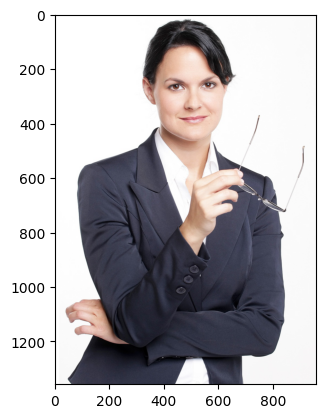

In [2]:
!wget -q -O image.png https://storage.googleapis.com/mediapipe-assets/business-person.png

import cv2

img = cv2.imread("image.png")
plt.imshow(img[:, :, ::-1])
plt.grid(False)

Optionally, you can upload your own image. If you want to do so, uncomment and run the cell below.

In [ ]:
# from google.colab import files
# uploaded = files.upload()

# for filename in uploaded:
#   content = uploaded[filename]
#   with open(filename, 'wb') as f:
#     f.write(content)

# if len(uploaded.keys()):
#   IMAGE_FILE = next(iter(uploaded))
#   print('Uploaded file:', IMAGE_FILE)

## Running inference and visualizing the results

Here are the steps to run face landmark detection using MediaPipe.

Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/face_landmarker/python) to learn more about configuration options that this task supports.


W0000 00:00:1774361838.033912   12017 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774361838.054848   12023 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774361838.064811   12023 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


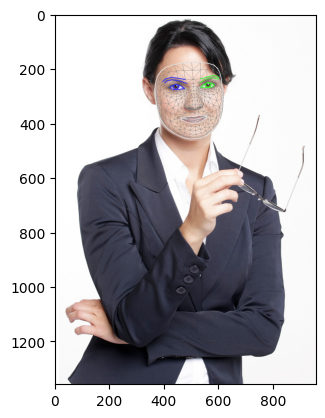

In [3]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an FaceLandmarker object.
base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("image.png")

# STEP 4: Detect face landmarks from the input image.
detection_result = detector.detect(image)

# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR)[:, :, ::-1])

We will also visualize the face blendshapes categories using a bar graph.

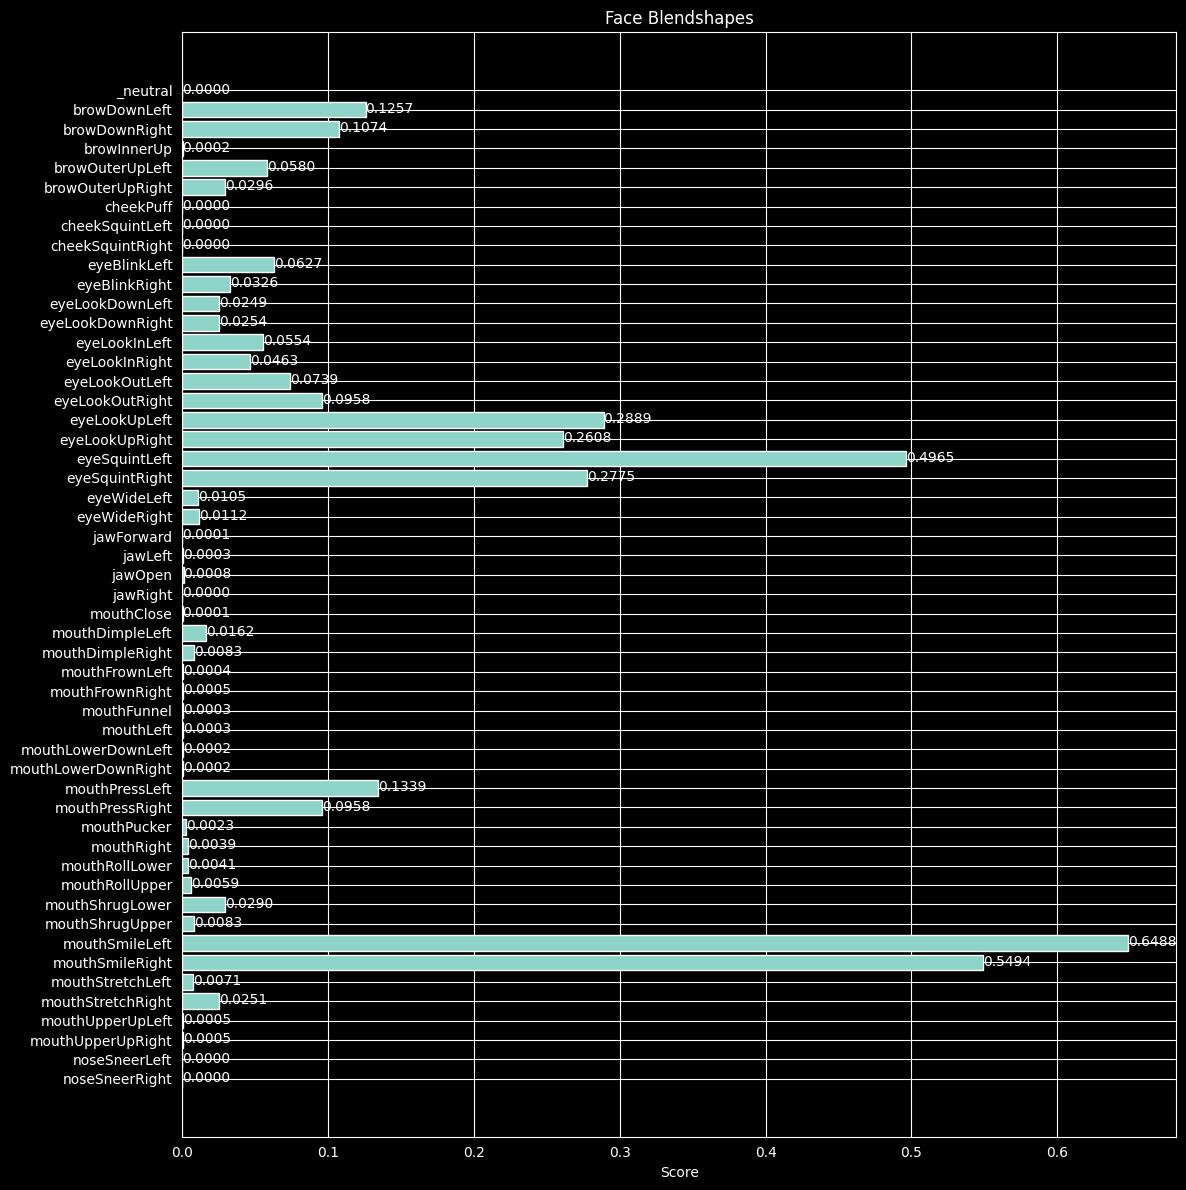

In [18]:
plot_face_blendshapes_bar_graph(detection_result.face_blendshapes[0])

And print the transformation matrix.

In [19]:
print(detection_result.facial_transformation_matrixes)

[array([[ 9.9220991e-01, -6.0496215e-02,  1.0890320e-01,  1.1874995e+00],
       [ 9.1046274e-02,  9.4880694e-01, -3.0245045e-01,  2.2372398e+01],
       [-8.5030966e-02,  3.1000933e-01,  9.4692349e-01, -6.8014664e+01],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  1.0000000e+00]],
      dtype=float32)]


In [9]:
import random
def get_random_frame(ruta_video):
    cap = cv2.VideoCapture(ruta_video)

    if not cap.isOpened():
        print("Error: No se pudo abrir el video.")
        return None

    # Obtener el número total de frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        print("Error: El video no tiene frames.")
        cap.release()
        return None

    # Elegir un índice al azar
    frame_id = random.randint(0, total_frames - 1)

    # Saltar directamente a ese frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)

    # Leer el frame
    ret, frame = cap.read()

    cap.release()

    if not ret:
        print(f"Error: No se pudo leer el frame {frame_id}.")
        return None

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    detection_result = detector.detect(mp_image)

    # STEP 5: Process the detection result. In this case, visualize it.
    annotated_image = draw_landmarks_on_image(mp_image.numpy_view(), detection_result)
    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
    return frame, annotated_image, detection_result, mp_image

# Uso del script
# frame = obtener_frame_alazar('mi_video.mp4')

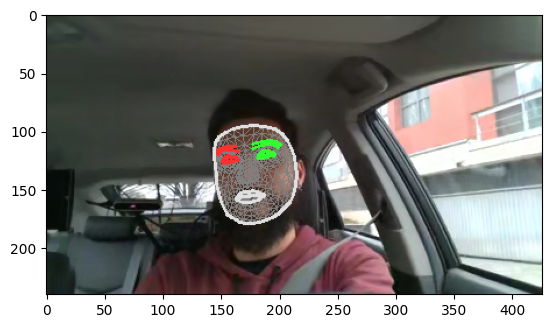

In [13]:
ruta = '/home/antares/Tesis_Data/VicomTech/dmd/gE/30/s3/output_240.mp4'
frame = get_random_frame(ruta)


In [6]:
frame[2]

FaceLandmarkerResult(face_landmarks=[[NormalizedLandmark(x=0.4206363260746002, y=0.6248576641082764, z=-0.026116497814655304, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.41796252131462097, y=0.5773651003837585, z=-0.03971468284726143, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.4193044900894165, y=0.5939034819602966, z=-0.023299716413021088, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.4105367660522461, y=0.5380364060401917, z=-0.02529691532254219, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.4171346426010132, y=0.5634621381759644, z=-0.0409073680639267, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.4164491295814514, y=0.5473226308822632, z=-0.03630051761865616, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.415237694978714, y=0.5102832913398743, z=-0.011781021021306515, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.37032750248908997, y

In [17]:
frame[0]

array([[[ 50,  60,  50],
        [ 50,  60,  50],
        [ 50,  60,  50],
        ...,
        [114, 129, 113],
        [115, 130, 114],
        [117, 131, 115]],

       [[ 51,  61,  51],
        [ 50,  60,  50],
        [ 49,  59,  48],
        ...,
        [114, 129, 113],
        [115, 130, 114],
        [117, 131, 115]],

       [[ 51,  61,  51],
        [ 50,  60,  50],
        [ 50,  60,  50],
        ...,
        [114, 129, 113],
        [115, 130, 114],
        [117, 131, 115]],

       ...,

       [[ 35,  41,  31],
        [ 33,  39,  29],
        [ 31,  36,  26],
        ...,
        [ 35,  39,  34],
        [ 40,  43,  40],
        [ 38,  45,  46]],

       [[ 35,  41,  31],
        [ 33,  39,  29],
        [ 31,  36,  26],
        ...,
        [ 36,  36,  36],
        [ 38,  40,  40],
        [ 41,  43,  45]],

       [[ 35,  41,  31],
        [ 33,  39,  29],
        [ 31,  36,  26],
        ...,
        [ 33,  34,  29],
        [ 33,  32,  34],
        [ 29,  30,  35]]

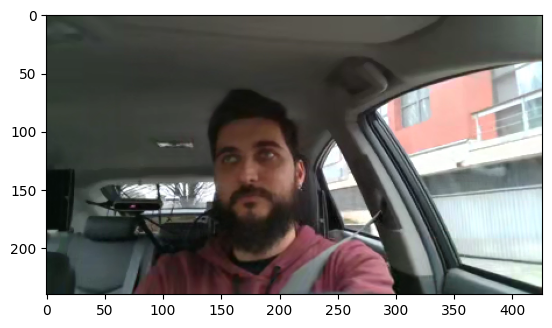

In [19]:
plt.imshow(frame[0][:, :, ::-1])
plt.grid(False)

In [7]:
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
detection_result = detector.detect(mp_image)

# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(mp_image.numpy_view(), detection_result)
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))

AttributeError: 'tuple' object has no attribute 'ndim'

In [42]:
import mediapipe as mp

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# Create a face landmarker instance with the video mode:
options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task'),
    running_mode=VisionRunningMode.VIDEO)

with FaceLandmarker.create_from_options(options) as landmarker:
    cap = cv2.VideoCapture(ruta)

    if not cap.isOpened():
        print("Error: No se pudo abrir el video.")

    # Obtener el número total de frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        print("Error: El video no tiene frames.")
        cap.release()

    for frame_id in range(total_frames):
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=numpy_frame_from_opencv)


W0000 00:00:1772715564.244374   15274 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1772715564.258361   15282 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772715564.273617   15280 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


NameError: name 'numpy_frame_from_opencv' is not defined